# LSB Steganography - Online Tool Compatible

This notebook encodes a hidden message into an image using LSB (Least Significant Bit) steganography.

## Method (Compatible with Online Tools):
- Uses RGB channels sequentially (R, G, B) across all pixels
- Message is encoded directly, followed by null terminator (0x00)
- **Compatible with:** stylesuxx.github.io/steganography, cypherchief, and similar online tools
- They read LSBs sequentially and stop at null bytes


In [36]:
from PIL import Image
import numpy as np


In [37]:
# Load the image
img_path = 'docs/images/steganpuzzle/raw.jpg'
img = Image.open(img_path)
img_array = np.array(img)

print(f"Image shape: {img_array.shape}")
print(f"Image size: {img.size}")


Image shape: (1280, 960, 3)
Image size: (960, 1280)


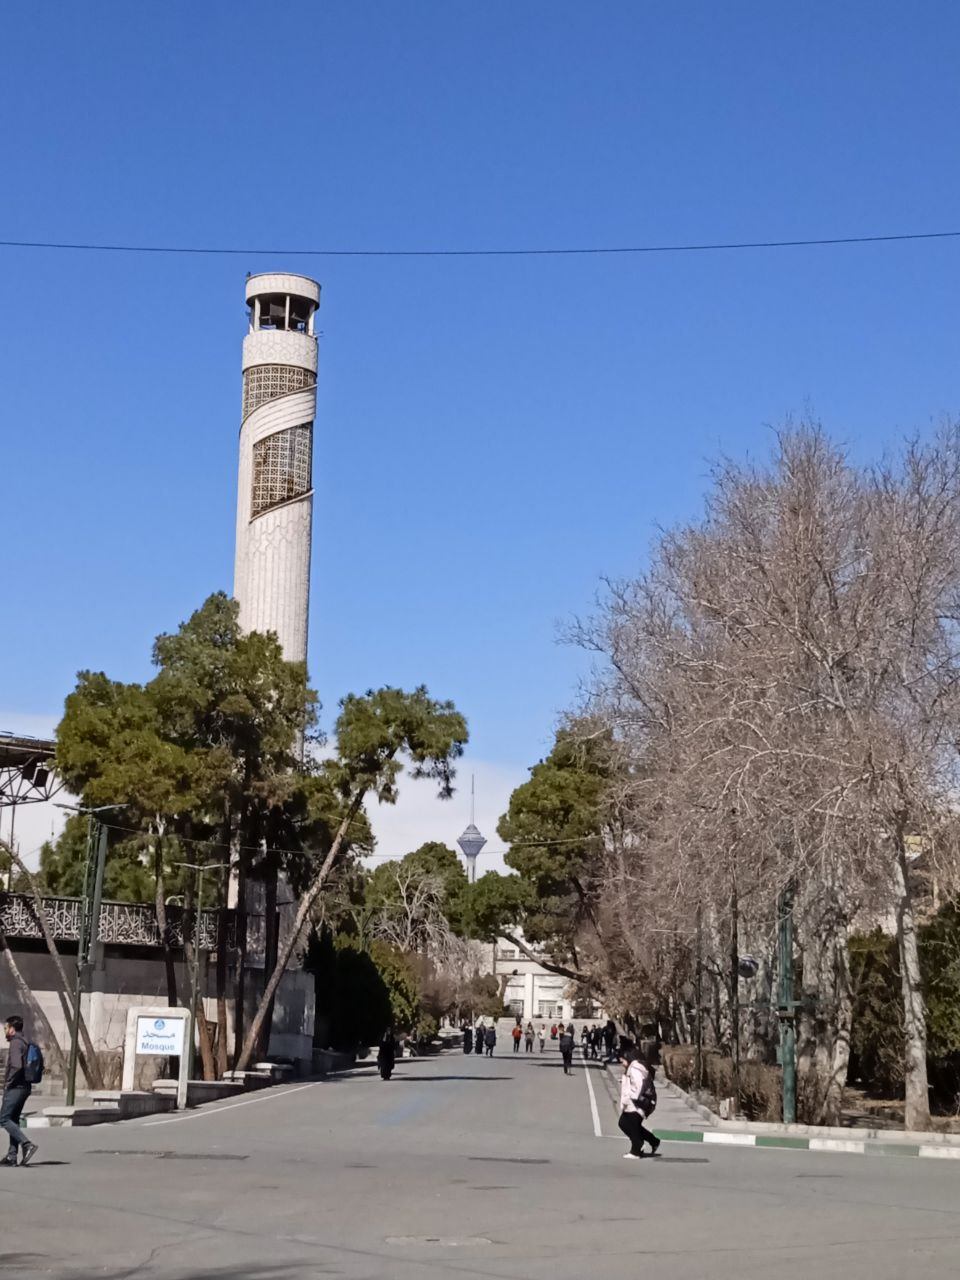

In [38]:
# Display the original image
img


In [39]:
# Message to encode
message = "good job! use this keyword to guess the final keyword. answer: PILLOW"
print(f"Message: {message}")
print(f"Message length: {len(message)} characters")


Message: good job! use this keyword to guess the final keyword. answer: PILLOW
Message length: 69 characters


In [28]:
def encode_lsb_online_compatible(img_array, message):
    """
    Encode message using LSB steganography compatible with online tools
    
    Online tools (stylesuxx, cypherchief, etc.) expect:
    - Message encoded sequentially across RGB channels
    - Null terminator (0x00) at the end to mark message end
    - NO length prefix (they read until null byte)
    
    Args:
        img_array: numpy array of the image (height, width, channels)
        message: string message to encode
    
    Returns:
        Modified image array with encoded message
    """
    # Create a copy to avoid modifying original
    encoded_img = img_array.copy()
    
    # Convert message to binary, then add null terminator (0x00 = 8 zeros)
    binary_message = ''.join(format(ord(char), '08b') for char in message)
    binary_message += '00000000'  # Null terminator (0x00) - online tools stop here
    
    print(f"Message length: {len(message)} characters")
    print(f"Binary message length: {len(binary_message)} bits (including null terminator)")
    
    # Get image dimensions
    height, width, channels = encoded_img.shape
    max_bits = height * width * channels  # Total available bits across RGB
    
    if len(binary_message) > max_bits:
        raise ValueError(f"Message too long! Maximum {max_bits} bits, got {len(binary_message)}")
    
    # Encode data sequentially across RGB channels
    bit_index = 0
    for i in range(height):
        for j in range(width):
            for c in range(channels):  # R, G, B channels
                if bit_index < len(binary_message):
                    # Get pixel value
                    pixel_value = encoded_img[i, j, c]
                    
                    # Clear the LSB and set it to the data bit
                    pixel_value = (pixel_value & 0xFE) | int(binary_message[bit_index])
                    
                    # Update the pixel
                    encoded_img[i, j, c] = pixel_value
                    
                    bit_index += 1
                else:
                    break
            if bit_index >= len(binary_message):
                break
        if bit_index >= len(binary_message):
            break
    
    print(f"✓ Successfully encoded {bit_index} bits into the image")
    print(f"✓ Used {bit_index / (height * width * channels) * 100:.2f}% of available capacity")
    print(f"✓ Compatible with online tools (stylesuxx.github.io/steganography, cypherchief, etc.)")
    return encoded_img


In [29]:
# Encode the message using ONLINE-COMPATIBLE method
encoded_array = encode_lsb_online_compatible(img_array, message)
print("\n✓ Message encoded successfully using online-compatible LSB method!")


Message length: 69 characters
Binary message length: 560 bits (including null terminator)
✓ Successfully encoded 560 bits into the image
✓ Used 0.02% of available capacity
✓ Compatible with online tools (stylesuxx.github.io/steganography, cypherchief, etc.)

✓ Message encoded successfully using online-compatible LSB method!


In [30]:
# Convert back to image and save
encoded_img = Image.fromarray(encoded_array)
output_path = 'docs/images/steganpuzzle/encoded.png'
encoded_img.save(output_path)
print(f"Encoded image saved to: {output_path}")


Encoded image saved to: docs/images/steganpuzzle/encoded.png


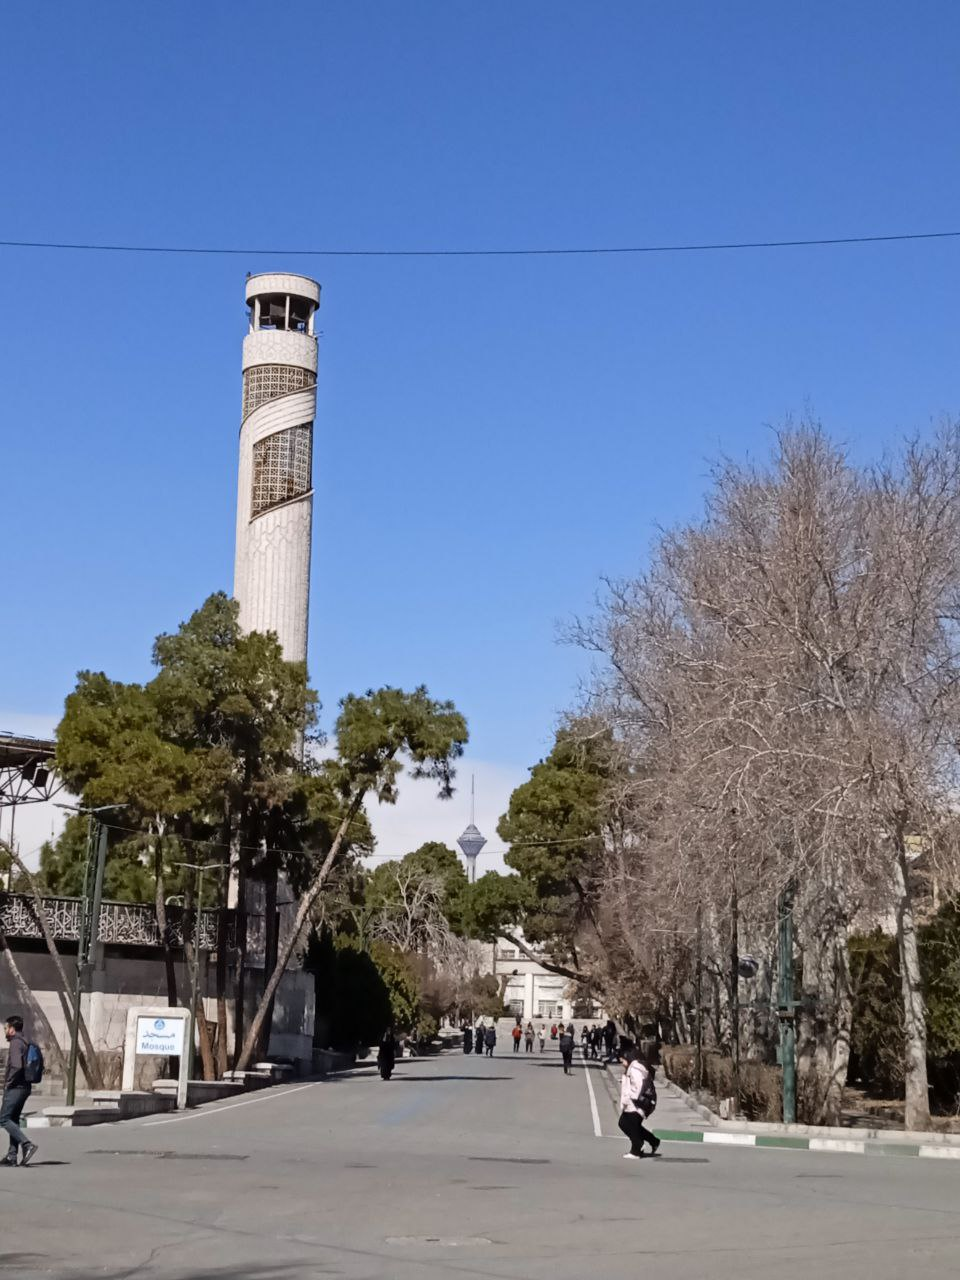

In [31]:
# Display the encoded image (should look identical to the original)
encoded_img


In [32]:
# Verify: Check the difference between original and encoded
diff = np.abs(img_array.astype(int) - encoded_array.astype(int))
print(f"Max difference: {diff.max()}")
print(f"Number of changed pixels (R channel): {np.sum(diff[:,:,0] > 0)}")
print(f"\nThe difference is minimal (max 1), making it invisible to the human eye!")


Max difference: 1
Number of changed pixels (R channel): 88

The difference is minimal (max 1), making it invisible to the human eye!


## Decoding Function (for verification)

Let's verify our encoding by decoding the message back. This also shows how online tools decode it.


In [33]:
def decode_lsb_online_compatible(img_array):
    """
    Decode message using ONLINE-COMPATIBLE LSB steganography method
    
    Online tools approach:
    - Read LSBs sequentially from RGB channels
    - Convert 8 bits at a time to characters
    - Stop when null byte (0x00) is encountered
    - This matches how stylesuxx.github.io/steganography and cypherchief work
    
    Args:
        img_array: numpy array of the image
    
    Returns:
        Decoded message string
    """
    height, width, channels = img_array.shape
    binary_data = ''
    
    # Extract LSBs sequentially from RGB channels
    for i in range(height):
        for j in range(width):
            for c in range(channels):  # R, G, B channels
                pixel_value = img_array[i, j, c]
                binary_data += str(pixel_value & 1)
    
    # Convert binary to text, stopping at null byte (0x00)
    message = ''
    for i in range(0, len(binary_data), 8):
        byte = binary_data[i:i+8]
        if len(byte) == 8:
            char_code = int(byte, 2)
            # Stop at null terminator (0x00)
            if char_code == 0:
                break
            # Only add printable characters (online tools often filter these)
            if 32 <= char_code <= 126 or char_code >= 128:  # Printable ASCII + extended
                message += chr(char_code)
            else:
                # Non-printable character - might be end of message
                break
    
    return message
    """
    Decode message using STANDARD LSB steganography method
    
    Standard approach:
    - First 32 bits contain the message length
    - Then extract that many bits and convert to text
    - Works with any standard LSB steganography tool
    
    Args:
        img_array: numpy array of the image
    
    Returns:
        Decoded message string
    """
    height, width, channels = img_array.shape
    binary_data = ''
    message_length = None  # Initialize to None
    
    # Extract LSBs sequentially from RGB channels
    for i in range(height):
        for j in range(width):
            for c in range(channels):  # R, G, B channels
                pixel_value = img_array[i, j, c]
                binary_data += str(pixel_value & 1)
                
                # Once we have 32 bits, we can read the length
                if len(binary_data) == 32:
                    message_length = int(binary_data, 2)
                    print(f"Detected message length: {message_length} bits ({message_length // 8} characters)")
                
                # If we've read length + message, we're done (only check after length is set)
                if message_length is not None and len(binary_data) >= 32 + message_length:
                    break
            if message_length is not None and len(binary_data) >= 32 + message_length:
                break
        if message_length is not None and len(binary_data) >= 32 + message_length:
            break
    
    # Check if we successfully read the length
    if message_length is None:
        return "Error: Could not read message length (not enough data or no message embedded)"
    
    # Extract the message (skip first 32 bits which contain length)
    message_binary = binary_data[32:32 + message_length]
    
    # Convert binary to text
    message = ''
    for i in range(0, len(message_binary), 8):
        byte = message_binary[i:i+8]
        if len(byte) == 8:
            message += chr(int(byte, 2))
    
    return message


In [34]:
# Decode and verify using ONLINE-COMPATIBLE method
print("=" * 60)
print("DECODING TEST (How online tools decode it)")
print("=" * 60)
decoded_message = decode_lsb_online_compatible(encoded_array)
print(f"\nDecoded message: {decoded_message}")
print(f"Original message: {message}")
print(f"\n✓ Match: {decoded_message == message}")
print("\n💡 This method works with:")
print("   - https://stylesuxx.github.io/steganography/")
print("   - cypherchief.com")
print("   - Most online LSB steganography tools")


DECODING TEST (How online tools decode it)

Decoded message: good job! use this keyword to guess the final keyword. answer: PILLOW
Original message: good job! use this keyword to guess the final keyword. answer: PILLOW

✓ Match: True

💡 This method works with:
   - https://stylesuxx.github.io/steganography/
   - cypherchief.com
   - Most online LSB steganography tools


## How to Decode (Standard Method)

The encoded image can now be decoded using any standard LSB steganography tool or the simple decoder below:

**Method:**
1. Read LSBs sequentially from RGB channels
2. First 32 bits = message length (as binary number)
3. Extract that many bits
4. Convert 8 bits at a time to ASCII characters

This is compatible with common tools like:
- `stegsolve` (Java-based)
- `zsteg` (Ruby gem)
- `steghide` (though uses different method)
- Custom Python scripts using the same standard


In [35]:
# Test decoding from the saved file (to verify it works after saving)
print("=" * 60)
print("TESTING DECODE FROM SAVED FILE")
print("=" * 60)
saved_img = Image.open('docs/images/steganpuzzle/encoded.png')
saved_array = np.array(saved_img)
decoded_from_file = decode_lsb_online_compatible(saved_array)
print(f"\nDecoded from saved file: {decoded_from_file}")
print(f"Original message: {message}")
print(f"\n✓ Saved file decode successful: {decoded_from_file == message}")
print("\n✅ Now you can upload 'encoded.png' to online tools and they will decode it!")


TESTING DECODE FROM SAVED FILE

Decoded from saved file: good job! use this keyword to guess the final keyword. answer: PILLOW
Original message: good job! use this keyword to guess the final keyword. answer: PILLOW

✓ Saved file decode successful: True

✅ Now you can upload 'encoded.png' to online tools and they will decode it!
